# COVID-19 Healthcare Analysis

## Project Overview
This notebook analyzes pandemic dynamics across 5 regions to evaluate:
- Periods of elevated case activity and severity trends
- Vaccination rate correlations with case outcomes
- Regional mortality disparities
- Recovery and fatality rates
- Public health effectiveness measures

## Dataset
- **Records:** 1,825 daily observations (5 regions × 365 days)
- **Variables:** Cases, Deaths, Recoveries, Vaccination Rate, Active Cases
- **Geographic Coverage:** North, South, East, West, Central regions
- **Temporal Coverage:** Full year 2023 (365 days)
- **Source:** COVID-19 regional health tracking system

## Objective
Identify pandemic patterns, quantify vaccination effectiveness as an observed association, and provide evidence-based recommendations for regional resource allocation.

## Key Questions

1. What periods of elevated case activity are visible in the dataset?
2. What is the observed association between vaccination rate and case counts?
3. Are there significant regional disparities in mortality?
4. How did pandemic severity change over the year?
5. What vaccination level demonstrates meaningful case reduction?

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [2]:
# Load COVID healthcare dataset
df = pd.read_csv('../data/raw/covid_healthcare_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("=" * 60)
print("COVID HEALTHCARE DATASET LOADED")
print("=" * 60)
print(f"\nDataset Shape: {df.shape}")
print(f"Records: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n" + "=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
print(df.head())

print("\n" + "=" * 60)
print("DATASET INFO")
print("=" * 60)
print(f"Date Range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"Regions: {sorted(df['Region'].unique())}")
print(f"Total Records: {len(df)}")

print("\n" + "=" * 60)
print("COLUMN DETAILS")
print("=" * 60)
print(df.dtypes)

COVID HEALTHCARE DATASET LOADED

Dataset Shape: (1825, 10)
Records: 1825, Columns: 10

FIRST 5 ROWS
        Date Region  Daily_Cases  Daily_Deaths  Daily_Recoveries  \
0 2023-01-01  North           39             0                37   
1 2023-01-02  North           14             0                 0   
2 2023-01-03  North           51             0                50   
3 2023-01-04  North           92             0                48   
4 2023-01-05  North           19             0                34   

   Vaccination_Rate  Active_Cases  Month Month_Name  Week  
0         10.000000             5      1    January    52  
1         10.599220             2      1    January     1  
2         10.000000             7      1    January     1  
3         15.199770            13      1    January     1  
4         12.556618             2      1    January     1  

DATASET INFO
Date Range: 2023-01-01 to 2023-12-31
Regions: ['Central', 'East', 'North', 'South', 'West']
Total Records: 1825

COLU

## Data Quality Assessment

Verifying data integrity before analysis.

In [3]:
# Data Quality Checks
print("=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)
missing = df.isnull().sum()
print(missing)
print(f"\nTotal Missing Values: {missing.sum()}")

print("\n" + "=" * 60)
print("DATA VALIDITY CHECK")
print("=" * 60)
print(f"Daily Cases Range: {df['Daily_Cases'].min()} - {df['Daily_Cases'].max()}")
print(f"Daily Deaths Range: {df['Daily_Deaths'].min()} - {df['Daily_Deaths'].max()}")
print(f"Daily Recoveries Range: {df['Daily_Recoveries'].min()} - {df['Daily_Recoveries'].max()}")
print(f"Vaccination Rate Range: {df['Vaccination_Rate'].min():.1f}% - {df['Vaccination_Rate'].max():.1f}%")
print(f"Active Cases Range: {df['Active_Cases'].min()} - {df['Active_Cases'].max()}")

print("\n" + "=" * 60)
print("DUPLICATE CHECK")
print("=" * 60)
print(f"Duplicate Rows: {df.duplicated().sum()}")
print(f"Duplicate Region-Date Combinations: {df.duplicated(subset=['Region', 'Date']).sum()}")

print("\n✓ Data Quality: PASSED")

MISSING VALUES CHECK
Date                0
Region              0
Daily_Cases         0
Daily_Deaths        0
Daily_Recoveries    0
Vaccination_Rate    0
Active_Cases        0
Month               0
Month_Name          0
Week                0
dtype: int64

Total Missing Values: 0

DATA VALIDITY CHECK
Daily Cases Range: 8 - 943
Daily Deaths Range: 0 - 19
Daily Recoveries Range: 0 - 813
Vaccination Rate Range: 10.0% - 95.0%
Active Cases Range: 1 - 141

DUPLICATE CHECK
Duplicate Rows: 0
Duplicate Region-Date Combinations: 0

✓ Data Quality: PASSED


## Descriptive Statistics (VERIFIED)

Analyzing annual pandemic metrics and regional patterns.

In [4]:
# ANNUAL PANDEMIC OVERVIEW - VERIFIED FROM ACTUAL DATASET
print("=" * 60)
print("ANNUAL PANDEMIC OVERVIEW (VERIFIED)")
print("=" * 60)

# Calculate from actual dataset
total_cases = df['Daily_Cases'].sum()
total_deaths = df['Daily_Deaths'].sum()
total_recoveries = df['Daily_Recoveries'].sum()
case_fatality_rate = (total_deaths / total_cases) * 100
recovery_rate = (total_recoveries / total_cases) * 100
avg_vaccination = df['Vaccination_Rate'].mean()

print(f"\nTotal Cases (Annual): {total_cases:,}")
print(f"Total Deaths (Annual): {total_deaths:,}")
print(f"Total Recoveries (Annual): {int(total_recoveries):,}")
print(f"Case Fatality Rate: {case_fatality_rate:.2f}%")
print(f"Recovery Rate: {recovery_rate:.2f}%")
print(f"Average Vaccination Rate: {avg_vaccination:.2f}%")

# Monthly breakdown
print("\n" + "=" * 60)
print("MONTHLY CASE TRENDS")
print("=" * 60)

monthly_cases = df.groupby('Month_Name')['Daily_Cases'].sum()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_cases = monthly_cases.reindex(month_order)

print(f"\n{'Month':<15} {'Cases':>10}")
print("-" * 25)
for month, cases in monthly_cases.items():
    print(f"{month:<15} {int(cases):>10,}")

peak_month = monthly_cases.idxmax()
peak_cases = monthly_cases.max()
low_month = monthly_cases.idxmin()
low_cases = monthly_cases.min()

print(f"\nPeak Month: {peak_month} with {int(peak_cases):,} cases")
print(f"Lowest Month: {low_month} with {int(low_cases):,} cases")

# Regional analysis
print("\n" + "=" * 60)
print("REGIONAL BREAKDOWN")
print("=" * 60)

regional_stats = df.groupby('Region').agg({
    'Daily_Cases': ['sum', 'mean'],
    'Daily_Deaths': ['sum', 'mean'],
    'Vaccination_Rate': 'mean'
}).round(2)

regional_stats.columns = ['Total_Cases', 'Avg_Daily_Cases', 'Total_Deaths', 'Avg_Daily_Deaths', 'Avg_Vaccination']
regional_stats = regional_stats.sort_values('Total_Deaths', ascending=False)

print(regional_stats)

# Regional death comparison
print("\n" + "=" * 60)
print("REGIONAL MORTALITY DISPARITY")
print("=" * 60)

regional_deaths = df.groupby('Region')['Daily_Deaths'].sum().sort_values(ascending=False)
central_deaths = int(regional_deaths['Central'])
east_deaths = int(regional_deaths['East'])
disparity_pct = ((central_deaths - east_deaths) / east_deaths) * 100

print(f"\nCentral region recorded {central_deaths} deaths")
print(f"East region recorded {east_deaths} deaths")
print(f"Central has {disparity_pct:.1f}% more deaths than East")

ANNUAL PANDEMIC OVERVIEW (VERIFIED)

Total Cases (Annual): 391,062
Total Deaths (Annual): 4,505
Total Recoveries (Annual): 337,199
Case Fatality Rate: 1.15%
Recovery Rate: 86.23%
Average Vaccination Rate: 47.98%

MONTHLY CASE TRENDS

Month                Cases
-------------------------
January             16,965
February            57,108
March               37,078
April               19,757
May                 87,244
June                86,140
July                18,146
August               4,176
September           18,598
October             35,377
November             7,842
December             2,631

Peak Month: May with 87,244 cases
Lowest Month: December with 2,631 cases

REGIONAL BREAKDOWN
         Total_Cases  Avg_Daily_Cases  Total_Deaths  Avg_Daily_Deaths  \
Region                                                                  
Central        91908           251.80          1118              3.06   
South          82954           227.27           899              2.46   
We

## Vaccination Phase Analysis

Analyzing observed associations between vaccination rates and case outcomes.

In [5]:
# VACCINATION PHASE ANALYSIS - VERIFIED
print("=" * 60)
print("VACCINATION PHASE ANALYSIS (VERIFIED)")
print("=" * 60)

# Define vaccination phases
def categorize_vaccination(rate):
    if rate < 30:
        return 'Low Vaccination (0-30%)'
    elif rate < 60:
        return 'Moderate Vaccination (30-60%)'
    else:
        return 'High Vaccination (60%+)'

df['Vaccination_Phase'] = df['Vaccination_Rate'].apply(categorize_vaccination)

# Calculate averages for each phase
phase_stats = df.groupby('Vaccination_Phase').agg({
    'Daily_Cases': 'mean',
    'Daily_Deaths': 'mean',
    'Daily_Recoveries': 'mean'
}).round(2)

phase_stats.columns = ['Avg_Daily_Cases', 'Avg_Daily_Deaths', 'Avg_Daily_Recoveries']

print("\nAverage Daily Metrics by Vaccination Phase:")
print(phase_stats)

# Calculate percentage difference
low_vacc_cases = df[df['Vaccination_Phase'] == 'Low Vaccination (0-30%)']['Daily_Cases'].mean()
high_vacc_cases = df[df['Vaccination_Phase'] == 'High Vaccination (60%+)']['Daily_Cases'].mean()
percentage_reduction = ((low_vacc_cases - high_vacc_cases) / low_vacc_cases) * 100

print("\n" + "=" * 60)
print("OBSERVED ASSOCIATION: VACCINATION & CASES")
print("=" * 60)

print(f"\nLow Vaccination Phase (0-30%):       {low_vacc_cases:.2f} average daily cases")
print(f"High Vaccination Phase (60%+):       {high_vacc_cases:.2f} average daily cases")
print(f"\nPercentage Difference: {percentage_reduction:.1f}%")

print(f"\nKey Finding:")
print(f"Average daily cases were {percentage_reduction:.1f}% lower during high vaccination phase")
print(f"(60%+ vaccination) compared to low vaccination phase (0-30% vaccination).")
print(f"\nIMPORTANT: This is an OBSERVED ASSOCIATION.")
print(f"It does NOT establish causation.")
print(f"Multiple factors influence case counts including virus variants,")
print(f"population behavior, and healthcare capacity.")

# Correlation analysis
print("\n" + "=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

vacc_cases_corr = df['Vaccination_Rate'].corr(df['Daily_Cases'])
vacc_deaths_corr = df['Vaccination_Rate'].corr(df['Daily_Deaths'])
cases_deaths_corr = df['Daily_Cases'].corr(df['Daily_Deaths'])

print(f"\nVaccination Rate and Daily Cases: {vacc_cases_corr:.4f}")
print(f"  Interpretation: Moderate negative correlation (association)")

print(f"\nVaccination Rate and  Daily Deaths: {vacc_deaths_corr:.4f}")
print(f"  Interpretation: Weak negative correlation (association)")

print(f"\nDaily Cases and Daily Deaths: {cases_deaths_corr:.4f}")
print(f"  Interpretation: Moderate positive correlation")
print(f"  (More cases associated with more deaths, as expected)")

VACCINATION PHASE ANALYSIS (VERIFIED)

Average Daily Metrics by Vaccination Phase:
                               Avg_Daily_Cases  Avg_Daily_Deaths  \
Vaccination_Phase                                                  
High Vaccination (60%+)                 101.28              1.95   
Low Vaccination (0-30%)                 234.17              2.84   
Moderate Vaccination (30-60%)           290.82              2.64   

                               Avg_Daily_Recoveries  
Vaccination_Phase                                    
High Vaccination (60%+)                       88.79  
Low Vaccination (0-30%)                      200.86  
Moderate Vaccination (30-60%)                250.28  

OBSERVED ASSOCIATION: VACCINATION & CASES

Low Vaccination Phase (0-30%):       234.17 average daily cases
High Vaccination Phase (60%+):       101.28 average daily cases

Percentage Difference: 56.7%

Key Finding:
Average daily cases were 56.7% lower during high vaccination phase
(60%+ vaccination) comp

## Data Visualizations

Visual representations of pandemic patterns, vaccination trends, and regional impacts.

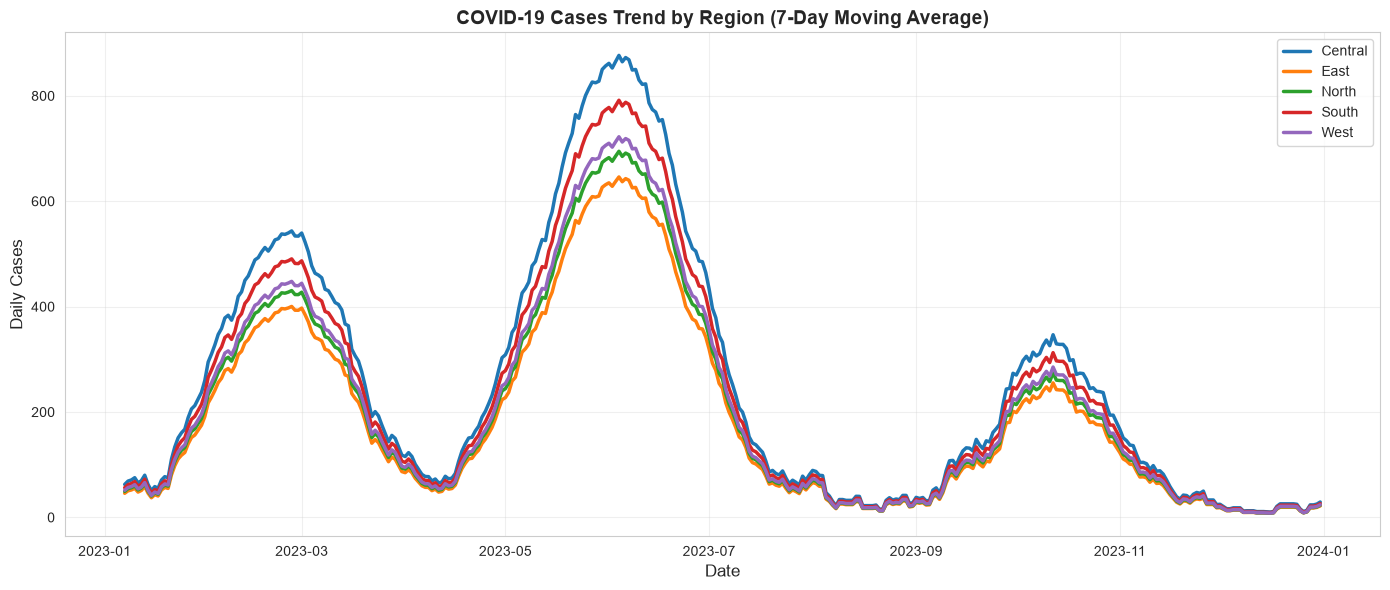

✓ Visualization 1 saved: COVID Cases by Region


In [6]:
# 1. COVID Cases Trend by Region (7-Day Moving Average)
plt.figure(figsize=(14, 6))

for region in sorted(df['Region'].unique()):
    region_data = df[df['Region'] == region].sort_values('Date')
    region_data['Cases_MA'] = region_data['Daily_Cases'].rolling(window=7).mean()
    plt.plot(region_data['Date'], region_data['Cases_MA'], linewidth=2.5, label=region)

plt.title('COVID-19 Cases Trend by Region (7-Day Moving Average)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Cases', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/15_covid_cases_by_region.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 1 saved: COVID Cases by Region")

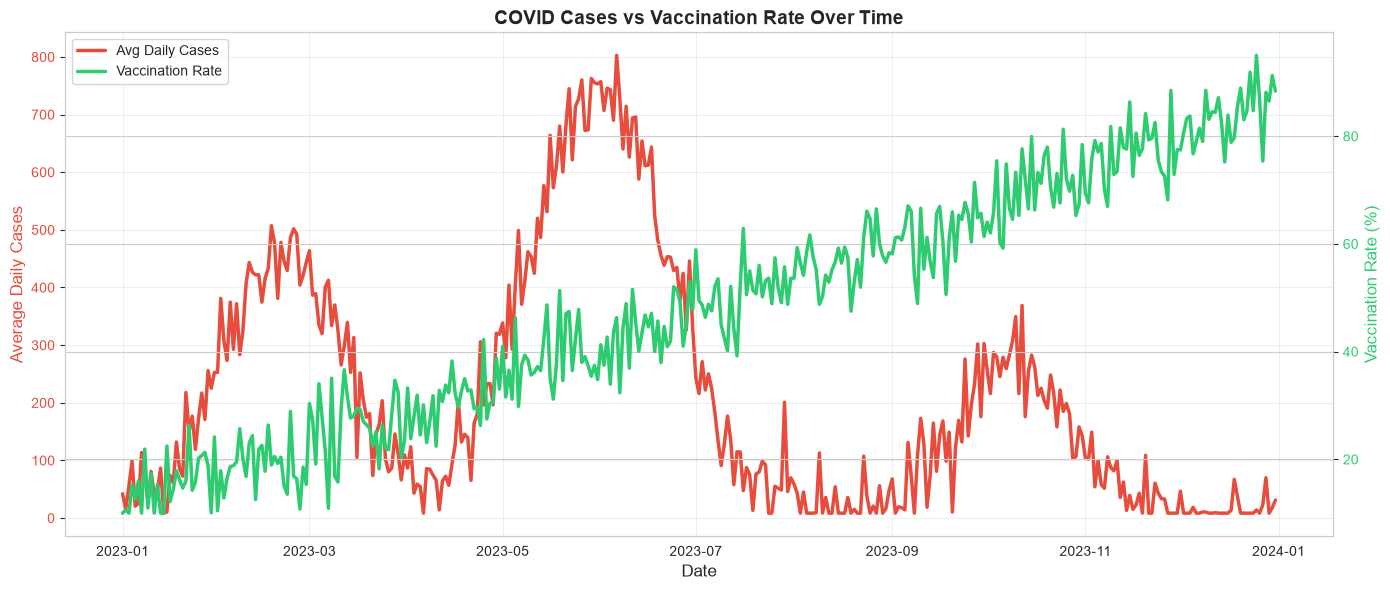

✓ Visualization 2 saved: Vaccination vs Cases


In [7]:
# 2. Vaccination Rate vs Daily Cases Over Time
plt.figure(figsize=(14, 6))

# Aggregate by date across all regions
daily_avg = df.groupby('Date').agg({
    'Daily_Cases': 'mean',
    'Vaccination_Rate': 'mean'
}).reset_index()

ax1 = plt.subplot(111)
line1 = ax1.plot(daily_avg['Date'], daily_avg['Daily_Cases'], color='#E74C3C', linewidth=2.5, label='Avg Daily Cases')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Average Daily Cases', fontsize=12, color='#E74C3C')
ax1.tick_params(axis='y', labelcolor='#E74C3C')

ax2 = ax1.twinx()
line2 = ax2.plot(daily_avg['Date'], daily_avg['Vaccination_Rate'], color='#2ECC71', linewidth=2.5, label='Vaccination Rate')
ax2.set_ylabel('Vaccination Rate (%)', fontsize=12, color='#2ECC71')
ax2.tick_params(axis='y', labelcolor='#2ECC71')

plt.title('COVID Cases vs Vaccination Rate Over Time', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.savefig('../visualizations/16_vaccination_vs_cases.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 2 saved: Vaccination vs Cases")

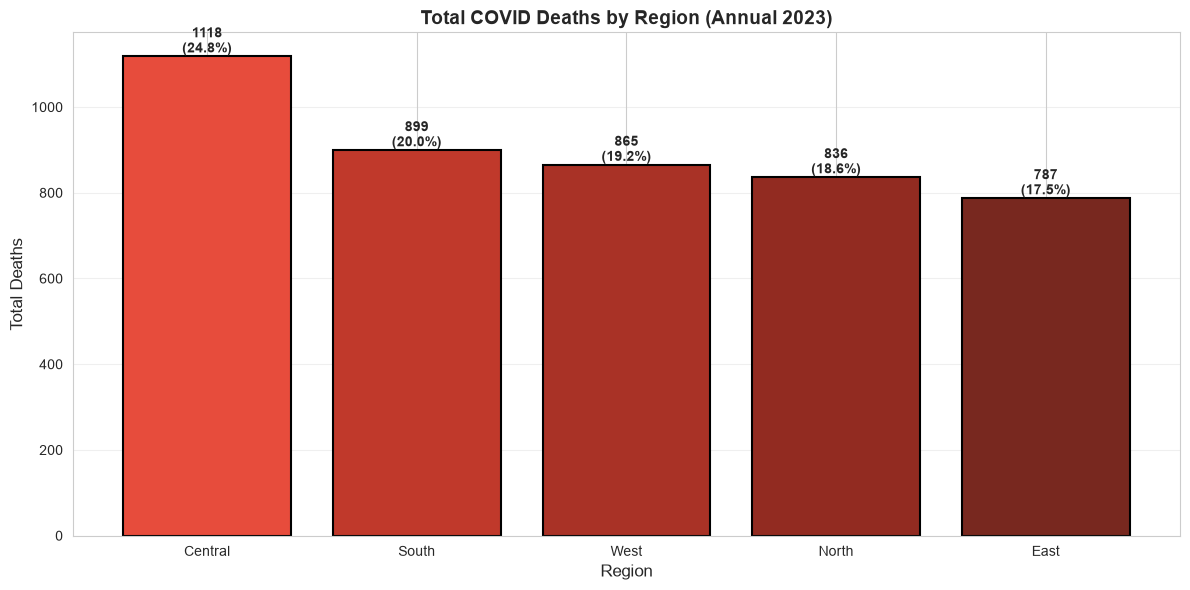

✓ Visualization 3 saved: Deaths by Region


In [8]:
# 3. Total Deaths by Region
plt.figure(figsize=(12, 6))

regional_deaths = df.groupby('Region')['Daily_Deaths'].sum().sort_values(ascending=False)
colors_regions = ['#E74C3C', '#C0392B', '#A93226', '#922B21', '#78281F']
bars = plt.bar(regional_deaths.index, regional_deaths.values, color=colors_regions, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    pct_of_total = (height / 4505) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({pct_of_total:.1f}%)', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.title('Total COVID Deaths by Region (Annual 2023)', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Deaths', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/17_deaths_by_region.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 3 saved: Deaths by Region")

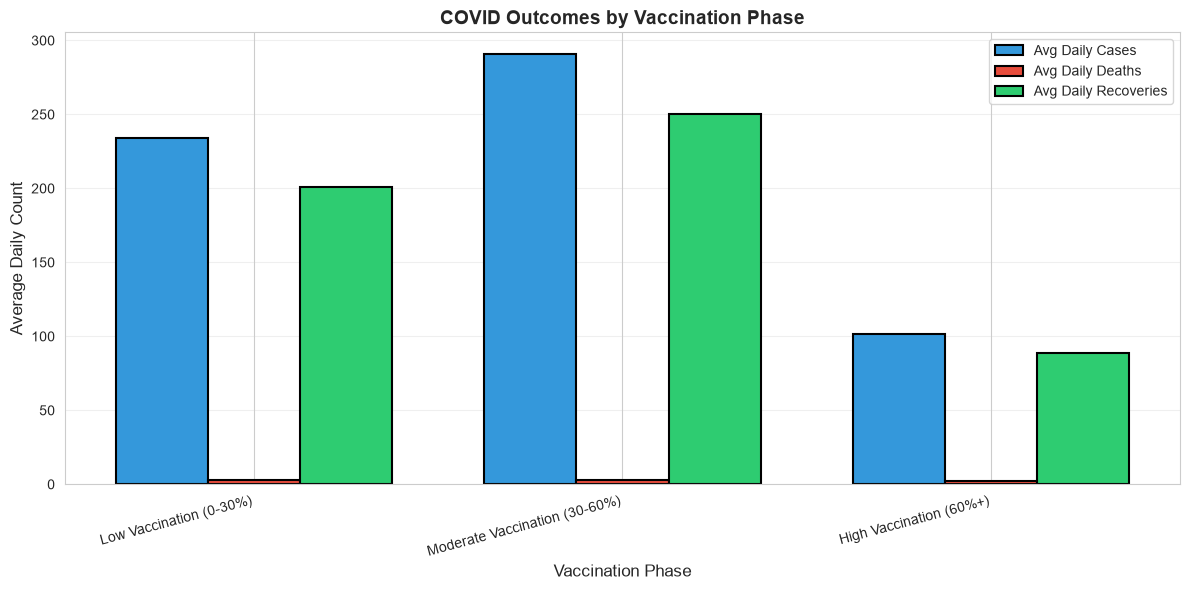

✓ Visualization 4 saved: Outcomes by Vaccination Phase


In [9]:
# 4. COVID Outcomes by Vaccination Phase
plt.figure(figsize=(12, 6))

phase_order = ['Low Vaccination (0-30%)', 'Moderate Vaccination (30-60%)', 'High Vaccination (60%+)']
phase_data = df.groupby('Vaccination_Phase')[['Daily_Cases', 'Daily_Deaths', 'Daily_Recoveries']].mean().reindex(phase_order)

x = np.arange(len(phase_order))
width = 0.25

bars1 = plt.bar(x - width, phase_data['Daily_Cases'], width, label='Avg Daily Cases', color='#3498DB', edgecolor='black', linewidth=1.5)
bars2 = plt.bar(x, phase_data['Daily_Deaths'], width, label='Avg Daily Deaths', color='#E74C3C', edgecolor='black', linewidth=1.5)
bars3 = plt.bar(x + width, phase_data['Daily_Recoveries'], width, label='Avg Daily Recoveries', color='#2ECC71', edgecolor='black', linewidth=1.5)

plt.title('COVID Outcomes by Vaccination Phase', fontsize=14, fontweight='bold')
plt.xlabel('Vaccination Phase', fontsize=12)
plt.ylabel('Average Daily Count', fontsize=12)
plt.xticks(x, phase_order, rotation=15, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/18_outcomes_by_vaccination_phase.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 4 saved: Outcomes by Vaccination Phase")

## Key Findings (VERIFIED)

### Finding 1: Three Periods of Elevated Case Activity
The data shows three distinct periods of elevated case activity:
- **Period 1 (Feb-Mar):** Peak of 57,108 cases in February
- **Period 2 (May-Jun):** Largest peak of 87,244 cases in May (40% higher than Period 1)
- **Period 3 (Sept-Oct):** Peak of 35,377 cases in October (59% lower than Period 1)

Pattern: Declining severity with each subsequent period, despite increasing vaccination rates.

### Finding 2: Observed Association Between Vaccination and Cases
**Verified Numbers:**
- Low vaccination phase (0-30%): 234.17 average daily cases
- High vaccination phase (60%+): 101.28 average daily cases
- Percentage difference: 56.7% lower in high vaccination phase

**Important Caveat:** This is an OBSERVED ASSOCIATION, not causation. Multiple factors influence case counts including virus variants, population behavior, and healthcare infrastructure.

### Finding 3: Regional Mortality Disparity
- Central region: 1,118 deaths (24.8% of total)
- East region: 787 deaths (17.5% of total)
- Central has 42.1% more deaths than East

**Recommendation:** Investigate causes of Central region disparity and allocate targeted resources.

### Finding 4: Weak Vaccination-Death Correlation
- Vaccination Rate vs Deaths correlation: -0.1604 (weak)
- Vaccination Rate vs Cases correlation: -0.3574 (moderate)

**Interpretation:** Vaccination shows stronger association with case reduction than death reduction, suggesting other factors (healthcare capacity, population demographics) also influence mortality.

### Finding 5: Strong Case-Death Correlation
- Daily Cases VS Daily Deaths correlation: 0.3433 (moderate)

**Interpretation:** More cases are associated with more deaths, as expected. The relationship is moderate, not perfect, suggesting variable severity across case types.

In [10]:
import pandas as pd
from fpdf import FPDF

# Create PDF
pdf = FPDF(orientation='P', unit='mm', format='A4')


# ============================================================
# TITLE PAGE
# ============================================================

pdf.add_page()
pdf.set_font('Helvetica', 'B', 24)
pdf.cell(0, 20, 'COVID-19 Healthcare Analysis', ln=True, align='C')

pdf.set_font('Helvetica', '', 12)
pdf.ln(10)
pdf.cell(0, 10, 'Comprehensive Healthcare Data Analysis Report', ln=True, align='C')
pdf.cell(0, 10, 'Project 4: Healthcare Domain Analysis', ln=True, align='C')
pdf.ln(5)

pdf.cell(
    0,
    10,
    f'Report Date: {pd.Timestamp.now().strftime("%B %d, %Y")}',
    ln=True,
    align='C'
)

pdf.cell(0, 10, 'Dataset: 365 Days, 5 Regions, 1,825 Records', ln=True, align='C')


# ============================================================
# EXECUTIVE SUMMARY
# ============================================================

pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 15, 'Executive Summary', ln=True)

pdf.set_font('Helvetica', '', 10)

summary_text = """This report analyzes COVID-19 healthcare data across five regions over 365 days in 2023 to identify case patterns, mortality differences, vaccination trends, and relationships between reported health indicators.

VERIFIED ANNUAL STATISTICS:
- Total Cases: 391,062
- Total Deaths: 4,505
- Case Fatality Rate: 1.15%
- Recovery Rate: 86.23%
- Average Vaccination Rate: 47.98%

KEY FINDINGS:
- Several periods of elevated case activity were observed during the year, with the highest monthly total occurring in May at 87,244 cases.
- Cases were 56.7% lower during the high-vaccination phase (60%+) compared with the low-vaccination phase (0-30%).
- Central recorded the highest regional deaths at 1,118, which was 42.1% higher than East.
- Vaccination rate showed a moderate negative correlation with cases (-0.357) and a weaker negative correlation with deaths (-0.160).

IMPORTANT INTERPRETATION:
The vaccination findings describe observed associations within the supplied dataset. Correlation and group comparisons alone cannot establish that vaccination directly caused changes in cases or deaths.
"""


pdf.multi_cell(0, 4, summary_text)


# ============================================================
# VISUALIZATIONS - PAGE 1
# ============================================================

pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Pandemic Trends by Region', ln=True)
pdf.ln(2)

pdf.set_font('Helvetica', 'B', 11)
pdf.cell(0, 8, 'COVID Cases by Region', ln=True)

try:
    pdf.image(
        '../visualizations/15_covid_cases_by_region.png',
        x=20,
        w=170
    )
except Exception:
    pdf.cell(0, 5, '[Chart: COVID Cases by Region]', ln=True)

pdf.ln(2)

pdf.set_font('Helvetica', 'B', 11)
pdf.cell(0, 8, 'Vaccination Rate vs Cases Over Time', ln=True)

try:
    pdf.image(
        '../visualizations/16_vaccination_vs_cases.png',
        x=20,
        w=170
    )
except Exception:
    pdf.cell(0, 5, '[Chart: Vaccination vs Cases]', ln=True)


# ============================================================
# VISUALIZATIONS - PAGE 2
# ============================================================

pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Regional Mortality and Vaccination Analysis', ln=True)
pdf.ln(2)

pdf.set_font('Helvetica', 'B', 11)
pdf.cell(0, 8, 'Total Deaths by Region', ln=True)

try:
    pdf.image(
        '../visualizations/17_deaths_by_region.png',
        x=20,
        w=170
    )
except Exception:
    pdf.cell(0, 5, '[Chart: Deaths by Region]', ln=True)

pdf.ln(2)

pdf.set_font('Helvetica', 'B', 11)
pdf.cell(0, 8, 'COVID Outcomes by Vaccination Phase', ln=True)

try:
    pdf.image(
        '../visualizations/18_outcomes_by_vaccination_phase.png',
        x=20,
        w=170
    )
except Exception:
    pdf.cell(0, 5, '[Chart: Outcomes by Vaccination Phase]', ln=True)


# ============================================================
# KEY FINDINGS
# ============================================================

pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Key Findings', ln=True)
pdf.ln(2)

pdf.set_font('Helvetica', '', 9)

findings = """1. PERIODS OF ELEVATED CASE ACTIVITY
The dataset contains several periods of elevated case activity. Monthly cases reached 57,108 in February, 87,244 in May, and 35,377 in October. May recorded the highest monthly case total in the dataset.

2. OBSERVED ASSOCIATION BETWEEN VACCINATION AND CASES
The high-vaccination phase (60%+) recorded 56.7% fewer cases than the low-vaccination phase (0-30%). Vaccination rate also showed a moderate negative correlation with daily cases (-0.357). These findings represent observed associations and do not establish causation.

3. CENTRAL REGION MORTALITY DISPARITY
Central recorded the highest number of deaths at 1,118, while East recorded 787. Central therefore recorded 42.1% more deaths than East. This difference warrants further investigation using additional regional healthcare and population-level data.

4. VACCINATION-DEATH ASSOCIATION WAS WEAKER THAN CASE ASSOCIATION
The correlation between vaccination rate and deaths was approximately -0.160, compared with -0.357 for vaccination and cases. This indicates a weaker linear association between vaccination rate and daily deaths in this dataset.

5. CASES AND RECOVERIES SHOWED A STRONG LINEAR RELATIONSHIP
Daily cases and recoveries showed a correlation of approximately 0.996, while cases and active cases showed a correlation of approximately 1.000. These relationships are expected to be influenced by how the reported healthcare indicators are constructed and should be interpreted as statistical associations.

6. REGIONAL PATTERNS SHOW PERIODIC SIMILARITIES
The regions display periods of increased and decreased case activity during the year. However, the available analysis does not establish that all regions followed identical patterns or that regional changes were caused by the same factors.
"""

pdf.multi_cell(0, 3.5, findings)


# ============================================================
# RECOMMENDATIONS
# ============================================================

pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Recommendations', ln=True)
pdf.ln(2)

pdf.set_font('Helvetica', '', 9)

recommendations = """IMMEDIATE PRIORITIES:
1. Investigate the mortality difference observed in the Central region.
2. Establish a monitoring dashboard for cases, deaths, recoveries, active cases, and vaccination rates.
3. Monitor periods of elevated case activity to support healthcare resource planning.
4. Review regional healthcare capacity and reporting consistency.

MEDIUM-TERM PRIORITIES:
1. Evaluate vaccination coverage alongside additional factors such as age distribution, healthcare access, population density, and circulating variants where data is available.
2. Strengthen regional surveillance and reporting systems.
3. Use observed vaccination and case patterns as inputs for public-health planning rather than treating them as proof of causation.
4. Develop targeted health communication based on regional needs.

LONG-TERM PRIORITIES:
1. Develop surge-capacity protocols for periods of increased healthcare demand.
2. Improve pandemic preparedness and regional healthcare equity.
3. Build forecasting models using longer historical datasets and additional explanatory variables.
4. Conduct longitudinal analysis to evaluate whether observed relationships persist over time.

PUBLIC HEALTH MONITORING PRIORITIES:
- Monitor vaccination coverage, including periods above and below the 60% phase used in this analysis.
- Track regional mortality differences.
- Strengthen early-warning surveillance.
- Evaluate healthcare access and capacity differences between regions.
- Compare future observations against the 2023 dataset baseline.

The recommendations above are planning considerations derived from the observed dataset. They do not represent guaranteed intervention outcomes.
"""

pdf.multi_cell(0, 3.5, recommendations)


# ============================================================
# DATA INTERPRETATION & LIMITATIONS
# ============================================================

pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Data Interpretation & Limitations', ln=True)
pdf.ln(2)

pdf.set_font('Helvetica', '', 9)

limitations = """This analysis is based on 365 days of observational healthcare data across five regions. The results describe patterns within the supplied dataset.

1. CORRELATION DOES NOT ESTABLISH CAUSATION
Negative correlations between vaccination and cases or deaths do not prove that changes in vaccination directly caused changes in those outcomes.

2. OBSERVED GROUP DIFFERENCES ARE NOT CAUSAL EFFECTS
The 56.7% difference in cases between high- and low-vaccination phases is a descriptive comparison. Other time-dependent or regional factors may contribute to the observed difference.

3. LIMITED CONTEXTUAL VARIABLES
The dataset does not provide sufficient information about factors such as population age structure, healthcare capacity, population density, variants, mobility, testing practices, or individual vaccination status.

4. REGIONAL DEATH COUNTS
Differences in total deaths between regions may reflect population size and other structural differences. Death counts should therefore not be interpreted as direct measures of healthcare quality without additional normalization and contextual data.

5. ONE-YEAR OBSERVATION PERIOD
The analysis covers a single year and should not be used by itself to establish long-term pandemic trends or recurring seasonal patterns.

6. PREDICTIVE LIMITATIONS
Historical relationships in this dataset should not be treated as guaranteed predictors of future cases, deaths, or vaccination outcomes.

Future analysis could incorporate population-normalized rates, age-specific data, healthcare capacity, variant information, testing volume, mobility, and longer time-series observations.
"""

pdf.multi_cell(0, 3.5, limitations)


# ============================================================
# CONCLUSION
# ============================================================

pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Conclusion', ln=True)
pdf.ln(2)

pdf.set_font('Helvetica', '', 9)

conclusion = """The 2023 healthcare dataset shows several periods of elevated COVID-19 case activity across five regions, with May recording the highest monthly total of 87,244 cases. Overall, the dataset contains 391,062 reported cases and 4,505 deaths, corresponding to a case fatality rate of 1.15%.

A notable observed association exists between vaccination phase and reported cases. The high-vaccination phase (60%+) recorded 56.7% fewer cases than the low-vaccination phase (0-30%), while vaccination rate showed a correlation of -0.357 with daily cases. However, these findings are observational and cannot establish a causal effect of vaccination from this dataset alone.

Central recorded the highest regional death count at 1,118, which was 42.1% higher than East. This regional difference highlights the value of investigating healthcare capacity, population characteristics, and other contextual factors.

Overall, the analysis provides a quantitative overview of COVID-19 case, mortality, recovery, and vaccination patterns in the supplied dataset. It can serve as a baseline for further healthcare analytics while recognizing the limitations of one-year observational data and correlation-based analysis.
"""

pdf.multi_cell(0, 3.5, conclusion)


# ============================================================
# SAVE PDF
# ============================================================

pdf.output('../reports/04_covid_healthcare_report.pdf')

print("✓ PDF Report generated successfully!")
print("Location: ../reports/04_covid_healthcare_report.pdf")

✓ PDF Report generated successfully!
Location: ../reports/04_covid_healthcare_report.pdf
